Weight sharing 설명

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import SimpleRNN, Dense, Input
from tensorflow.keras import Sequential

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# from google.colab import files
# uploded = files.upload()

In [3]:
%cd drive/MyDrive/Colab Notebooks/Graduate/Graduate_Class_2025

/content/drive/MyDrive/Colab Notebooks/Graduate/Graduate_Class_2025


In [43]:
raw_df = pd.read_csv("Naver_All.csv", header=0)
raw_df

,Date,Open,Close,High,Low
0,2025-11-19,61400,60600,61800,59400
1,2025-11-18,63100,60800,64000,60100
2,2025-11-17,62900,63900,64400,62200
3,2025-11-14,63700,62800,65900,62300
4,2025-11-13,62000,65200,65200,61600
...,...,...,...,...,...
481,2023-11-24,37400,36850,37450,36800
482,2023-11-23,37450,37300,37650,37050
483,2023-11-22,37000,37050,37250,36850
484,2023-11-21,37350,37350,37800,37100


In [44]:
raw_df = raw_df.sort_values(by='Date', ascending=True)
raw_df

,Date,Open,Close,High,Low
485,2023-11-20,36800,36850,37000,36600
484,2023-11-21,37350,37350,37800,37100
483,2023-11-22,37000,37050,37250,36850
482,2023-11-23,37450,37300,37650,37050
481,2023-11-24,37400,36850,37450,36800
...,...,...,...,...,...
4,2025-11-13,62000,65200,65200,61600
3,2025-11-14,63700,62800,65900,62300
2,2025-11-17,62900,63900,64400,62200
1,2025-11-18,63100,60800,64000,60100


In [45]:
close = raw_df['Close']
close_np = close.to_numpy()
close_reshape = close_np.reshape(-1,1)                                          # reshape(-1,1) 2D 로 해야 scaling에서 에러 안남
close_reshape.shape

(486, 1)

In [46]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
seq_data = scaler.fit_transform(close_reshape)

print(seq_data.shape)

(486, 1)


In [47]:
max(seq_data)

array([1.])

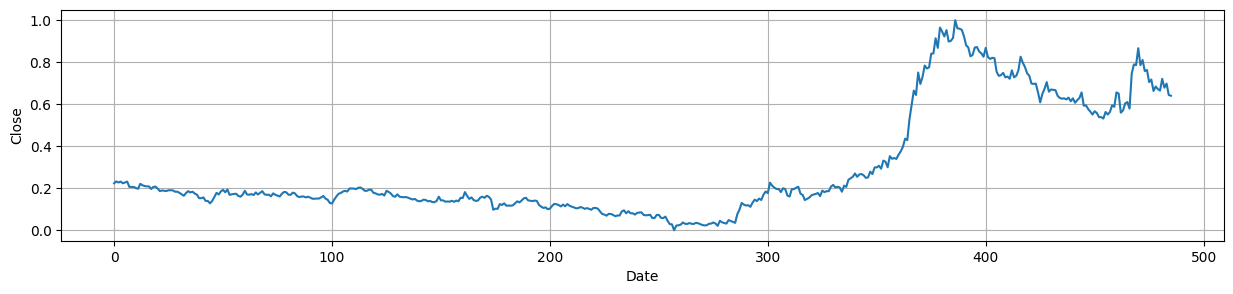

In [48]:
plt.figure(figsize=(15,3))

plt.plot(seq_data)

plt.xlabel('Date')
plt.ylabel('Close')
plt.grid()

plt.show()

In [49]:
def seq2dataset(seq, window, horizon):
  X = []
  Y = []

  for i in range(len(seq)-(window+horizon) + 1):                                # 1000-(50+1)+1 : 950번 반복
    x = seq[i:(i+window)]                                                       # y data (seq_data) 중에서 0부터 49번째까지 50개를 잘라서 x에 할당
    y = seq[i+window+horizon-1]                                                 # y data (seq_data) 중에서 50번째를 y에 할당 (앞에 50개를 통해서 51번째를 예측할 거니까)

    X.append(x)                                                                 # 50개를 1개의 세트로 잘라서 X에 추가해 나감 (X는 50개짜리 연속데이터(1세트)가 950세트 들어감)
    Y.append(y)                                                                 # Y에는 50개짜리 데이터의 그 다음 숫자 1개씩이 950개 들어감
  return np.array(X), np.array(Y)

w = 50                                                                          # window size(기본 50)를 증가시며가며 관찰
h = 1                                                                           # 얼마나 멀리 예측할 것인가?
X, Y = seq2dataset(seq_data, w, h)
print(X.shape, Y.shape)

(436, 50, 1) (436, 1)


In [50]:
split_ratio = 0.7

split = int(split_ratio * len(X))                                               # 950개 데이터중에 split_ratio(0.7)의 비율로 분리 예정

x_train = X[0:split]                                                            # 950세트의 X data중에서 70%를 x_train에 할당
y_train = Y[0:split]                                                            # 950개의 Y data중에서 70%를 y_train에 할당

x_test = X[split:]                                                              # 30%는 test data로 할당
y_test = Y[split:]

print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(305, 50, 1) (305, 1) (131, 50, 1) (131, 1)


In [51]:
x_train[0].shape

(50, 1)

In [58]:
model = Sequential()

model.add(Input(shape=x_train[0].shape))
model.add(SimpleRNN(units=64, activation='tanh'))              # 기본 units=128, units을 1부터 차례로 증가시켜가며 파라미터 변화와 fit 특성 관찰
model.add(Dense(1))

model.compile(loss='mse', optimizer='adam', metrics=['mae'])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
hist = model.fit(x_train, y_train, epochs=200, validation_split=0.1)

Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0153 - mae: 0.0978 - val_loss: 6.1610e-04 - val_mae: 0.0208
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0018 - mae: 0.0332 - val_loss: 0.0057 - val_mae: 0.0723
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 9.8833e-04 - mae: 0.0248 - val_loss: 0.0014 - val_mae: 0.0341
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 7.6797e-04 - mae: 0.0220 - val_loss: 0.0036 - val_mae: 0.0567
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 6.0958e-04 - mae: 0.0187 - val_loss: 0.0017 - val_mae: 0.0372
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 5.6002e-04 - mae: 0.0182 - val_loss: 0.0022 - val_mae: 0.0428
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 4.9935e-04 - mae: 0.0169 - val_loss: 0.0016 - val_mae: 0.0365
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 4.6752e-04 - mae: 0.0164 - val_loss: 0.0017 - val_mae: 0.0370
Epoch 9/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms

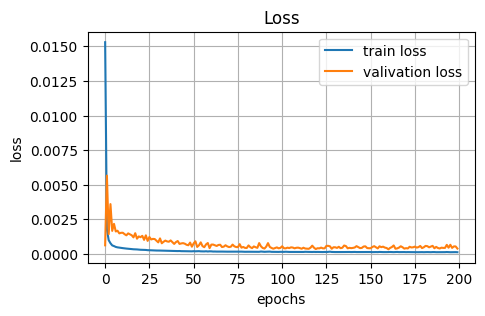

In [60]:
plt.figure(figsize=(5,3))

plt.plot(hist.history['loss'], label='train loss')
plt.plot(hist.history['val_loss'], label='valivation loss')

plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
# plt.yscale('log')

plt.legend(loc='best')
plt.grid()
plt.show()

In [61]:
pred_train = model.predict(x_train)
pred_test = model.predict(x_test)

print(pred_train.shape)
print(pred_test.shape)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
(305, 1)
(131, 1)


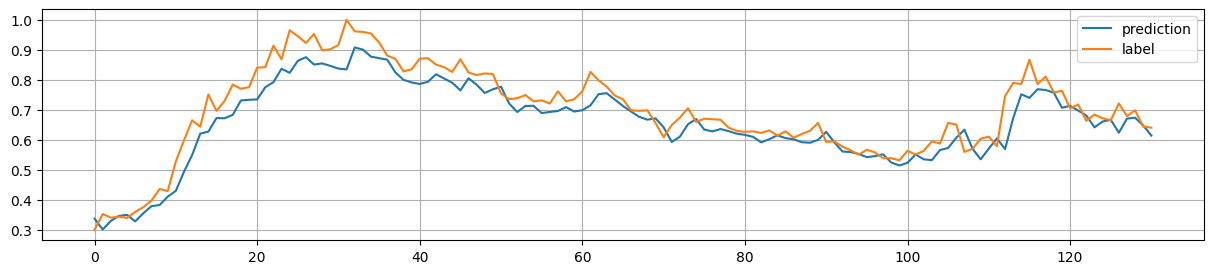

In [62]:
plt.figure(figsize=(15,3))

plt.plot(pred_test, label='prediction')
plt.plot(y_test, label='label')

plt.legend(loc='best')
plt.grid()
plt.show()

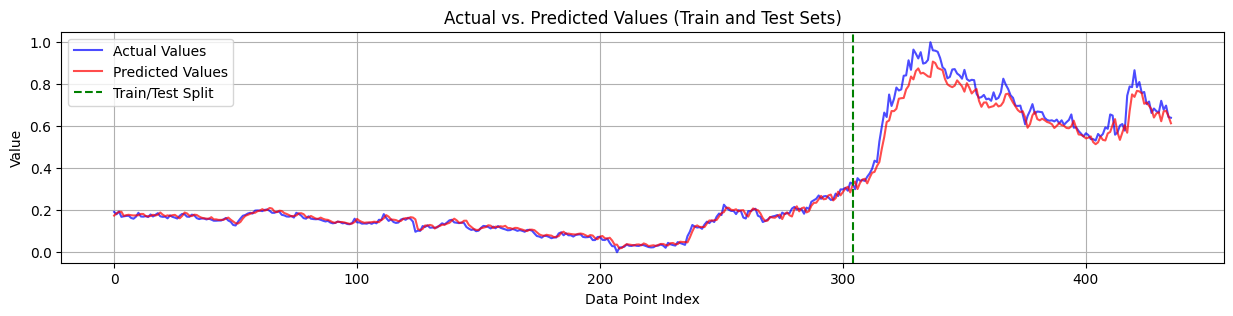

In [63]:
plt.figure(figsize=(15,3))

all_actual = np.concatenate((y_train, y_test), axis=0)
all_predictions = np.concatenate((pred_train, pred_test), axis=0)

plt.plot(all_actual, label='Actual Values', color='blue', alpha=0.7)
plt.plot(all_predictions, label='Predicted Values', color='red', alpha=0.7)

plt.axvline(x=len(y_train) - 1, color='green', linestyle='--', label='Train/Test Split')          # Add a vertical line to indicate the train/test split

plt.title('Actual vs. Predicted Values (Train and Test Sets)')
plt.xlabel('Data Point Index')
plt.ylabel('Value')

plt.legend(loc='best')
plt.grid()
plt.show()